In [47]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jr
import jax.scipy.special as jss
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
from dustmaps.edenhofer2023 import Edenhofer2023Query
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.table import Table

jax.config.update("jax_enable_x64", True)

def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, logscale, lognu = inference_params
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return result


def matern_magnitude(omega, inference_params):
    return jnp.sqrt(general_matern_spectral_density(omega, inference_params))

def get_omegas(L, N):
     return 2*jnp.pi*jnp.fft.fftfreq(N, d = L/N)



def fft_field_hartley(noise, fourier_length, num_fourier_entries, num_entries, inference_params):
    size = noise.shape[0]
    omegas = get_omegas(fourier_length, num_fourier_entries)
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    normalization_factor = num_fourier_entries/jnp.sqrt(fourier_length)
    H = noise * raw_average_amplitude_data         
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_entries]

def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)



In [48]:
with fits.open("../Data_And_Samplers/samples_healpix.fits") as hdul:
    hdul.info()
    pix = hp.pixelfunc.ang2pix(256, theta=0.0, phi=0.0, nest=True, lonlat=True)
    samples_gc = hdul["SAMPLES"].data[:, :, pix]          
    radii = hdul["radial pixel centers"].data["radial pixel centers"]  
    inner_samples_gc = hdul["INTEGRATED INNER 68.8 PC"].data[:, pix]   # (12,)

with fits.open("../Data_And_Samplers/mean_and_std_healpix.fits") as hdul:
    hdul.info()
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_dust_data_along_galactic_center = hdul["MEAN"].data[:, galactic_center_healpix]
    std_dust_data_along_galactic_center = hdul["STD."].data[:, galactic_center_healpix]
    healpix_size = hdul["MEAN"].data[0, :].size
    data_x = hdul['RADIAL PIXEL CENTERS'].data.field(0)
    distance_boundaries = hdul['RADIAL PIXEL BOUNDARIES'].data.field(0)
    mean_integrated_inner_galactic_center = hdul["MEAN OF INTEGRATED INNER 68.8 PC"].data[galactic_center_healpix]
    std_integrated_inner_galactic_center  = hdul["STD. OF INTEGRATED INNER 68.8 PC"].data[galactic_center_healpix]
    distance_gaps = np.diff(distance_boundaries)
    integrated_dust = np.dot(distance_gaps, hdul["MEAN"].data)

inner_samples_gc = jnp.asarray(np.ascontiguousarray(inner_samples_gc).astype(np.float32))
samples_gc = jnp.asarray(np.ascontiguousarray(samples_gc).astype(np.float32))
mean_dust_data_along_galactic_center = jnp.asarray(np.ascontiguousarray(mean_dust_data_along_galactic_center).astype(np.float32))
log_samples = jnp.log(samples_gc)
radii = jnp.asarray(np.ascontiguousarray(radii).astype(np.float32))

Filename: ../Data_And_Samplers/samples_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  SAMPLES       1 ImageHDU        21   (786432, 516, 12)   float32   
  2  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  3  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  4  INTEGRATED INNER 68.8 PC    1 ImageHDU        18   (786432, 12)   float32   


Filename: ../Data_And_Samplers/mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   


In [49]:
def cumulative_trapezoid(y, dx):
    seg = dx * (y[:-1] + y[1:]) / 2.0            # area of each trapezoid segment
    return jnp.concatenate([jnp.zeros(1, y.dtype), jnp.cumsum(seg)])

def exponentiated_integrated_density(logdensity):
    density = jnp.exp(logdensity)
    return cumulative_trapezoid(density, dx)

overall_data_arr = jnp.asarray(np.load("../sherlock_results_2/overall_data_Gaia_XP_fitting_actual_data_40345618_combined.npy"))
left_distance_padding = 40
right_distance_padding = 600
num_dimensions = 600
num_fourier_dimensions = 6000
min_distance = distance_boundaries[0] - left_distance_padding
max_distance = distance_boundaries[distance_boundaries.size - 1] + right_distance_padding
dx = (max_distance - min_distance)/(num_dimensions - 1)
fourier_length = dx*(num_fourier_dimensions - 1)
fixed_logscale = jnp.log(2*(max_distance - min_distance))

logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
logscales = jnp.ones_like(lognus)*fixed_logscale
offsets = overall_data_arr[:, 2]
inference_params = (logvars, logscales, lognus)
overall_extinction_arr = overall_data_arr[:, 3:3 + num_fourier_dimensions]

overall_extinction_arr_raw_before_offsets = jax.vmap(fft_field_hartley, in_axes=(0, None, None, None, 0))(
    overall_extinction_arr, fourier_length, num_fourier_dimensions, num_dimensions, inference_params
)
overall_extinction_arr_raw = overall_extinction_arr_raw_before_offsets + offsets[:, None]

overall_extinction_arr_exp = jax.vmap(exponentiated_integrated_density, in_axes=(0))(
    overall_extinction_arr_raw
)


num_lower_indices_to_cut = int(round(left_distance_padding / dx))
num_upper_indices_to_cut = int(round(right_distance_padding / dx))

n = overall_extinction_arr_raw.shape[1]
overall_extinction_arr_trimmed = overall_extinction_arr_raw[
    :, num_lower_indices_to_cut : n - num_upper_indices_to_cut
]

overall_extinction_arr_exp_trimmed = overall_extinction_arr_exp[
    :, num_lower_indices_to_cut : n - num_upper_indices_to_cut
]



In [50]:
def dist_to_plx(dist):
    return 1000/dist

def get_x_err_basic(plx_err, plx):
    return 1000*(plx**(-2))*plx_err

print(f"Mean integrated inner is {mean_integrated_inner_galactic_center}")
print(f"Std integrated inner is {std_integrated_inner_galactic_center}")

Mean integrated inner is 0.002952493727207184
Std integrated inner is 0.0004854228172916919


In [51]:
from hmc_dust import DATA, GAIA
fits_table = Table.read(GAIA / "gc_sightline.fits")

gc_builtin = SkyCoord(0*u.deg, 0*u.deg, frame='galactic').icrs

star_coords = SkyCoord(np.asarray(fits_table["ra"])*u.deg, np.asarray(fits_table["dec"])*u.deg)
fits_table["sep_gc_deg"] = star_coords.separation(gc_builtin).deg


plx_np = fits_table["parallax"]              # parallax measurements (mas)
plx = jnp.asarray(np.asarray(plx_np).astype(np.float32))
plx_err_np = fits_table["parallax_err"]         # their uncertainties (mas)
plx_err = jnp.asarray(np.asarray(plx_err_np).astype(np.float32))
ext_np  = fits_table["ext"]                  # extinction
ext = jnp.asarray(np.asarray(ext_np).astype(np.float32))
ext_err_np = fits_table["ext_err"]
ext_err = jnp.asarray(np.asarray(ext_err_np).astype(np.float32))
sep_np = fits_table["sep_gc_deg"]
separation = jnp.asarray(np.asarray(sep_np).astype(np.float32))
print(fits_table.info())

x_obs = dist_to_plx(plx)
y_obs = ext


mask = (separation < 0.3) & (plx - plx_err > 1000/1800) & (plx + plx_err < 1000/40)
x_obs = x_obs[mask]
y_obs = y_obs[mask]
plx_obs = plx[mask]
data_ext_err = ext_err[mask]
data_plx_err = plx_err[mask]
x_error = jax.vmap(get_x_err_basic)(plx_err[mask], plx_obs)
num_data = x_obs.size

<Table length=54602>
     name       dtype 
-------------- -------
gdr3_source_id   int64
            ra float32
           dec float32
      parallax float32
  parallax_err float32
           ext float32
       ext_err float32
        teff_K float32
           feh float32
          logg float32
  plx_over_err float32
    sep_gc_deg float64
None


(12, 516)
(4, 389)


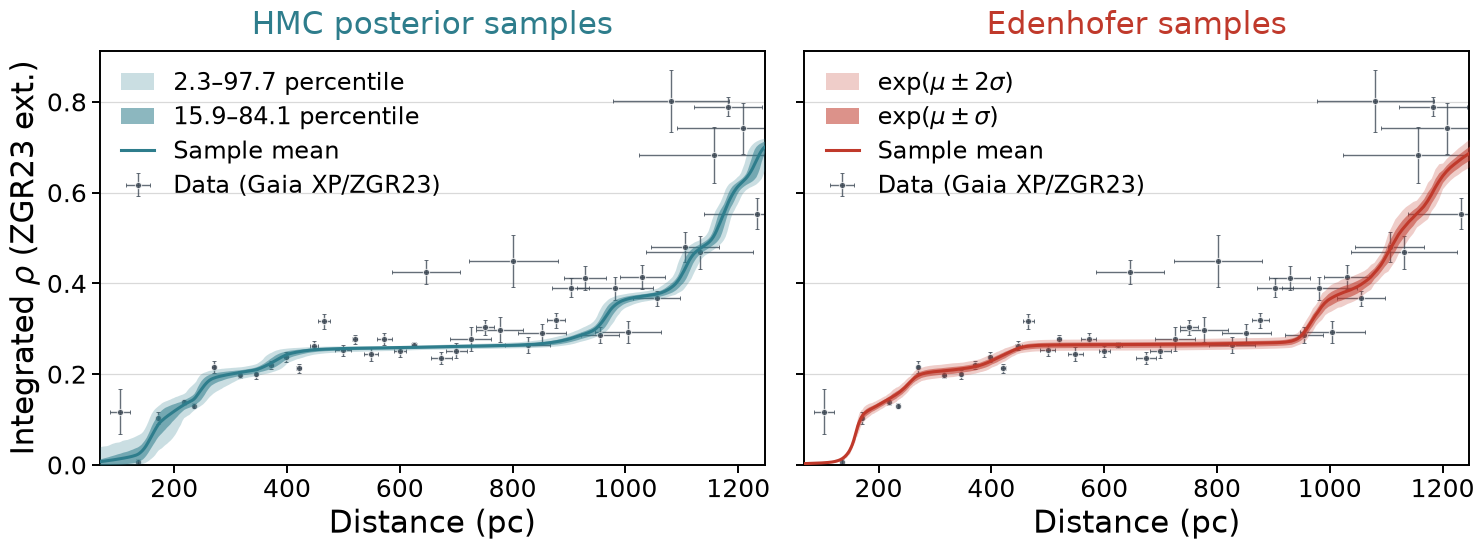

In [78]:
from scipy.stats import norm
print(samples_gc.shape)
distance_gaps = np.diff(distance_boundaries)
plotting_samples_linspace = (jnp.arange(n - num_lower_indices_to_cut - num_upper_indices_to_cut)*dx
                             + (min_distance + dx*num_lower_indices_to_cut))


def cumulative_column_density(samples_gc, distance_gaps):
    """Cumulative integral of cell-centered densities, evaluated at cell edges."""
    samples_gc = jnp.atleast_2d(samples_gc)
    distance_gaps = jnp.asarray(distance_gaps)

    if samples_gc.shape[1] != distance_gaps.size:
        raise ValueError(
            f"samples_gc has {samples_gc.shape[1]} cells but "
            f"distance_gaps has {distance_gaps.size} widths"
        )

    seg = samples_gc * distance_gaps                      
    zeros = jnp.zeros((samples_gc.shape[0], 1), dtype=seg.dtype)
    return jnp.concatenate([zeros, jnp.cumsum(seg, axis=1)], axis=1)

integrated_samples = cumulative_column_density(samples_gc, distance_gaps)
integrated_samples = integrated_samples + inner_samples_gc[:, None]
integrated_mean = jnp.mean(integrated_samples, axis = 0)
log_integrated_samples = jnp.log(integrated_samples)
log_integrated_mean = jnp.mean(log_integrated_samples, axis = 0)
log_integrated_std = jnp.std(log_integrated_samples, axis  = 0)


log_hmc = jnp.log(overall_extinction_arr_exp_trimmed)
log_hmc_mean = jnp.mean(log_hmc, axis = 0)
log_hmc_std = jnp.std(log_hmc, axis = 0)




hmc_mean = jnp.mean(overall_extinction_arr_exp_trimmed, axis = 0)
z = np.array([-2, -1, 1, 2])
important_percentiles = norm.cdf(z) * 100
sigma_boundaries_array = np.percentile(overall_extinction_arr_exp_trimmed,
                                       important_percentiles, axis=0)   # (4, n_cols)

sigma_boundaries_array_samples = jnp.exp(
    log_integrated_mean + log_integrated_std * z[:, None]
)

print(sigma_boundaries_array.shape)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ------------------------------------------------------------------ style
C_HMC  = "#2E7D8C"     # teal  (HMC)
C_EDEN = "#C0392B"     # red   (Edenhofer)
C_OBS  = "#3F4A56"     # slate — neutral against both panel colors
A_OUT, A_IN = 0.25, 0.55

N_ERRORBARS = 45       # target number of points drawn (same set in both panels)

mpl.rcParams.update({
    "axes.linewidth": 1.4,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 6, "ytick.major.size": 6,
    "xtick.major.width": 1.4, "ytick.major.width": 1.4,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
    "axes.labelsize": 22, "legend.fontsize": 17,
    "savefig.bbox": "tight", "savefig.dpi": 300,
})

# ------------------------------------------------------------------ data
hmc_bands = np.asarray(sigma_boundaries_array)            # (4, n) [-2s,-1s,+1s,+2s]
ed_bands  = np.asarray(sigma_boundaries_array_samples)    # (4, n)

x_hmc, y_hmc = np.asarray(plotting_samples_linspace), np.asarray(hmc_mean)
x_ed         = np.asarray(distance_boundaries)
y_ed         = np.exp(np.asarray(log_integrated_mean))

# observations
x_o  = np.asarray(x_obs)
y_o  = np.asarray(y_obs)
ye_o = np.asarray(ext_err[mask])
xe_o = np.asarray(x_error)
xe_o = np.broadcast_to(xe_o, x_o.shape) if np.ndim(xe_o) else np.full_like(x_o, xe_o)

# shared x-window: the overlap of the two model grids
X_LO = max(x_hmc.min(), x_ed.min())
X_HI = min(x_hmc.max(), x_ed.max())


def thin_even_in_x(x, n_target):
    """Pick ~n_target indices spread evenly across the x-range, one per bin."""
    x = np.asarray(x)
    if x.size <= n_target:
        return np.arange(x.size)
    edges = np.linspace(x.min(), x.max(), n_target + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    which = np.clip(np.digitize(x, edges) - 1, 0, n_target - 1)
    keep = []
    for b, c in enumerate(centers):
        pool = np.flatnonzero(which == b)
        if pool.size:
            keep.append(pool[np.argmin(np.abs(x[pool] - c))])   # closest to bin center
    return np.asarray(keep)


# ---- selected ONCE, then reused in both panels ----
in_range = np.flatnonzero((x_o >= X_LO) & (x_o <= X_HI))
SEL = in_range[thin_even_in_x(x_o[in_range], N_ERRORBARS)]


def draw_errorbars(ax):
    """Observed points, identical in every panel. Returns the legend handle."""
    return ax.errorbar(
        x_o[SEL], y_o[SEL], yerr=ye_o[SEL], xerr=xe_o[SEL],
        fmt="o", markersize=4.5,
        markerfacecolor=C_OBS, markeredgecolor="white", markeredgewidth=0.7,
        color=C_OBS,                 # marker + bar color
        ecolor=C_OBS, elinewidth=1.0, capsize=1.5,
        alpha=0.8, zorder=2,
        label="Data (Gaia XP/ZGR23)",
    )

# ------------------------------------------------------------------ figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6), sharex=True, sharey=True)

panels = [
    (axes[0], x_hmc, y_hmc, hmc_bands, C_HMC,  "HMC posterior samples",
     ("2.3–97.7 percentile", "15.9–84.1 percentile")),
    (axes[1], x_ed,  y_ed,  ed_bands,  C_EDEN, "Edenhofer samples",
     (r"$\exp(\mu \pm 2\sigma)$", r"$\exp(\mu \pm \sigma)$")),
]

for ax, x, mean, bands, color, title, (lbl_out, lbl_in) in panels:
    lo2, lo1, hi1, hi2 = bands

    obs_handle = draw_errorbars(ax)

    # bands go on top of the data, but stay readable
    ax.fill_between(x, lo2, hi2, color=color, alpha=A_OUT, lw=0, zorder=3)
    ax.fill_between(x, lo1, hi1, color=color, alpha=A_IN,  lw=0, zorder=4)
    ax.plot(x, mean, color=color, lw=2.2, solid_capstyle="round", zorder=5)

    ax.set_title(title, color=color, fontsize=22, pad=12)
    ax.set_xlabel("Distance (pc)")
    ax.yaxis.grid(True, color="0.85", lw=0.9)
    ax.set_axisbelow(True)

    handles = [
        Patch(facecolor=color, alpha=A_OUT, label=lbl_out),
        Patch(facecolor=color, alpha=A_IN,  label=lbl_in),
        Line2D([], [], color=color, lw=2.2, label="Sample mean"),
        obs_handle
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False,
              handlelength=1.4, borderpad=0.4, labelspacing=0.45)

# shared axis limits (sharex/sharey means setting one sets both)
axes[0].set_xlim(X_LO, X_HI)
y_top = max(hmc_bands[3].max(), ed_bands[3].max(),
            np.percentile(y_o[SEL] + ye_o[SEL], 99))
axes[0].set_ylim(0, y_top * 1.08)
axes[0].set_ylabel(r"Integrated $\rho$ (ZGR23 ext.)")
fig.tight_layout()
fig.subplots_adjust(wspace=0.06)
fig.savefig("integrated_extinction.pdf")
fig.savefig("integrated_extinction.png")
plt.show()